# Anisotropic MeanFlow with α_t Interpolant

**Interpolant formulation:** `z_t = (1 - α_t) ⊙ x + α_t ⊙ ε`

where:
- `α_t = 0` for observed pixels (no noise, stays at data)
- `α_t = t` for masked pixels (interpolates from 0→1 as t goes from 0→1, i.e., from data→noise)
- `⊙` denotes element-wise (Hadamard) product
- At t=0: all pixels are data; At t=1: masked pixels are noise, observed pixels stay as data

**Key features:**
- Spatial conditioning: α_t is interpolated to match each U-Net layer resolution
- Fixed mask structure (box inpainting)
- Modified MeanFlow loss with Jacobian correction terms

In [1]:
# !pip install -q -U einops datasets matplotlib tqdm

%load_ext autoreload
%autoreload 2

import os
import torch
from torch import nn
from torch import einsum
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import MNIST
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from IPython import display
from tqdm import tqdm

import math
from inspect import isfunction
from functools import partial

from einops import rearrange

from training.networks_amf import SongUNet, AMFPrecond

plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['image.cmap'] = 'gray'

os.makedirs('save', exist_ok=True)

## Utility Functions

In [2]:
def grid(array, ncols=8):
    array = np.pad(array, [(0,0),(1,1),(1,1),(0,0)], 'constant')
    nindex, height, width, intensity = array.shape
    ncols = min(nindex, ncols)
    nrows = (nindex+ncols-1)//ncols
    r = nrows*ncols - nindex
    arr = np.concatenate([array]+[np.zeros([1,height,width,intensity])]*r)
    result = (arr.reshape(nrows, ncols, height, width, intensity)
              .swapaxes(1,2)
              .reshape(height*nrows, width*ncols, intensity))
    return np.pad(result, [(1,1),(1,1),(0,0)], 'constant')

class NextDataLoader(torch.utils.data.DataLoader):
    def __next__(self):
        try:
            return next(self.iterator)
        except:
            self.iterator = self.__iter__()
            return next(self.iterator)

def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

## Mask Generation

Generate binary masks where:
- `mask = 1`: observed pixels
- `mask = 0`: pixels to inpaint

**Random box sizes:** During training, box sizes are randomized from 1 pixel to the full image size for better generalization!

In [3]:
def generate_box_mask(batch_size, channels, height, width, box_size=16, device='cuda'):
    """
    Generate center box masks for inpainting.
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box)
    """
    mask = torch.ones(batch_size, channels, height, width, device=device)
    start = (height - box_size) // 2
    end = start + box_size
    mask[:, :, start:end, start:end] = 0
    return mask

def generate_random_box_mask(batch_size, channels, height, width, min_box_size=1, max_box_size=None, device='cuda'):
    """
    Generate center box masks with RANDOM box sizes for each sample in the batch.
    
    Args:
        batch_size: number of samples
        channels: number of channels
        height, width: image dimensions
        min_box_size: minimum box size (default: 1 pixel)
        max_box_size: maximum box size (default: full image size)
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box with random size per sample)
    """
    if max_box_size is None:
        max_box_size = min(height, width)
    
    masks = []
    for _ in range(batch_size):
        # Randomly sample box size for this sample
        box_size = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        
        # Create mask for this sample
        mask = torch.ones(channels, height, width, device=device)
        start = (height - box_size) // 2
        end = start + box_size
        mask[:, start:end, start:end] = 0
        masks.append(mask)
    
    return torch.stack(masks, dim=0)

def generate_random_mask(batch_size, channels, height, width, mask_ratio=0.5, device='cuda'):
    """
    Generate random pixel masks for inpainting.
    
    Args:
        mask_ratio: proportion of pixels to mask
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked
    """
    mask = torch.rand(batch_size, channels, height, width, device=device)
    mask = (mask > mask_ratio).float()
    return mask

## Alpha Schedule and Interpolant

**Alpha schedule (Standard Diffusion Convention):**
- `α_t = (1 - mask) * t`
- Observed pixels (mask=1): `α_t = 0` (always at data)
- Masked pixels (mask=0): `α_t = t` (goes from 0→1, i.e., data→noise)

**Interpolant:**
- `z_t = (α_t) ⊙ x + (1 - α_t) ⊙ ε`
- At t=1: `z_1 = x` (all data)
- At t=0: `z_0 = mask ⊙ x + (1-mask) ⊙ ε` (observed=data, masked=noise)

**Velocity:**
- `dz_t/dt = -x·dα_t/dt + ε·dα_t/dt = (ε - x)·dα_t/dt`
- `dα_t/dt = (1 - mask)` (only masked pixels change)
- `v = (1 - mask) ⊙ (ε - x)`

In [4]:
# def compute_alpha_t(t, mask):
#     """
#     Compute α_t from time and mask.

#     Args:
#         t: time parameter [B, 1, 1, 1], ranges from 0 (data) to 1 (noise)
#         mask: binary mask [B, C, H, W], 1 = observed, 0 = masked

#     Returns:
#         α_t: [B, C, H, W]
#     """
#     # α_t = (1 - mask) * (1 -t
#     # Observed (mask=1): α_t = 1 (always at data)
#     # Masked (mask=0): α_t = t (goes from data to noise)
#     # alpha_t = mask + (1 - mask) * t
#     alpha_t = (1 - mask) * (1 - t)
#     return alpha_t

def compute_alpha_t(t, mask):
    """
    Compute α_t from time and mask.
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        t: time parameter [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
    Returns:
        α_t: [B, C, H, W]
        - Observed (mask=1): α_t = 1 (always clean)
        - Masked  (mask=0): α_t = t (interpolates noise→data as t: 0→1)
    """
    alpha_t = mask + (1 - mask) * t
    return alpha_t


def sample_interpolant(x, t, mask, eps=None):
    """
    Sample from the interpolant: z_t = α_t ⊙ x + (1 - α_t) ⊙ ε
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        x: clean data [B, C, H, W]
        t: time [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
        eps: noise (optional, will sample if not provided)
    Returns:
        z_t: interpolated sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        eps: noise used [B, C, H, W]
        v_true: true velocity field [B, C, H, W]
        drift: (x - eps) [B, C, H, W]
    """
    if eps is None:
        eps = torch.randn_like(x)

    # alpha=1 clean, alpha=0 noise
    # Observed (mask=1): alpha=1 always → z = x
    # Masked  (mask=0): alpha=t → t=1: z=x, t=0: z=eps
    alpha_t = compute_alpha_t(t, mask)

    # Interpolant: z_t = alpha_t * x + (1 - alpha_t) * eps
    z_t = alpha_t * x + (1 - alpha_t) * eps

    # Velocity: dz/dt = d(alpha_t)/dt * (x - eps)
    # d(alpha_t)/dt = (1 - mask)
    drift = x - eps
    v_true = (1 - mask) * drift

    return z_t, alpha_t, eps, v_true, drift

## Jacobian Computation for Anisotropic Loss

We need to compute:
- `(∇_z u_θ) @ v`: Jacobian w.r.t. z in direction v
- `(∇_{α} u_θ) @ dα/dt`: gradient w.r.t. α in direction dα/dt

In [5]:
def compute_jacobian_correction(net, z_t, alpha_t, alpha_s, dalpha_dt, t, h, v_true):
    """
    Compute Jacobian correction terms using JVP.
    
    Args:
        net: neural network
        z_t: noisy sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        dalpha_dt: time derivative of alpha [B, C, H, W]
        t: time [B, 1, 1, 1]
        h: auxiliary parameter [B, 1, 1, 1]
        v_true: true velocity [B, C, H, W]
    
    Returns:
        jvp_z: (∇_z u_θ) @ v_true
        jvp_alpha: (∇_{α} u_θ) @ dalpha_dt
    """
    # Take first channel of alpha_t for spatial conditioning
    alpha_spatial_t = alpha_t[:, :1, :, :]  # [B, 1, H, W]
    alpha_spatial_s = alpha_s[:, :1, :, :]  # [B, 1, H, W]

    # JVP w.r.t. z in direction v_true
    def u_wrapper_z(z):
        return net(z, alpha_spatial_t, alpha_spatial_s)
    _, jvp_z = torch.func.jvp(u_wrapper_z, (z_t,), (v_true,))
    
    # JVP w.r.t. alpha in direction dalpha_dt
    dalpha_spatial = dalpha_dt[:, :1, :, :]  # [B, 1, H, W]
    def u_wrapper_alpha(alpha):
        return net(z_t, alpha, alpha_spatial_s)
    _, jvp_alpha = torch.func.jvp(u_wrapper_alpha, (alpha_spatial_t,), (dalpha_spatial,))
    
    return jvp_z, jvp_alpha

## Anisotropic MeanFlow Loss

**Modified loss:**
```
u_target = v - (α_t - α_s) ⊙ [(∇_z u_θ) @ v + (∇_{α} u_θ) @ dα/dt]
loss = E[||u_θ - u_target||²]
```

In [10]:
# class AnisotropicFlowMap:
#     def __init__(
#         self,
#         P_mean=-0.4,
#         P_std=1.0,
#         noise_dist='logit_normal',
#         data_proportion=0.75,
#         norm_p=1.0,
#         norm_eps=1.0,
#     ):
#         self.P_mean = P_mean
#         self.P_std = P_std
#         self.data_proportion = data_proportion
#         self.norm_p = norm_p
#         self.norm_eps = norm_eps
#         self.noise_dist = noise_dist

#     def _logit_normal_dist(self, shape, device):
#         rnd_normal = torch.randn(shape, device=device)
#         return torch.sigmoid(rnd_normal * self.P_std + self.P_mean)

#     def _uniform_dist(self, shape, device):
#         return torch.rand(shape, device=device)

#     def noise_distribution(self, shape, device):
#         if self.noise_dist == 'logit_normal':
#             return self._logit_normal_dist(shape, device)
#         elif self.noise_dist == 'uniform':
#             return self._uniform_dist(shape, device)
#         else:
#             raise ValueError(f"Unknown noise distribution: {self.noise_dist}")

#     def __call__(self, net, images, masks):
#         """
#         Args:
#             net: network with call net(x, alpha_source, alpha_target)
#             images: clean images [B, C, H, W]
#             masks: binary masks [B, C, H, W], 1 = observed, 0 = masked
        
#         Convention: x_t = alpha_t * x + (1 - alpha_t) * eps
#         - Higher alpha = cleaner (alpha=1 is clean, alpha=0 is noise)
#         - Flow: X_{r,t}(x_r) = x_r + (alpha_t - alpha_r) * v
#         - r is source (noisier, lower alpha)
#         - t is target (cleaner, higher alpha)
#         """
#         x = images
#         device = x.device
#         batch_size = x.shape[0]
#         shape = (batch_size, 1, 1, 1)

#         # Sample r <= t (r is noisy source, t is clean target)
#         r_sample = self.noise_distribution(shape, device)
#         t_sample = self.noise_distribution(shape, device)
#         r, t = torch.min(r_sample, t_sample), torch.max(r_sample, t_sample)
#         # Now: r < t, so alpha_r < alpha_t (r noisier, t cleaner)

#         # Apply data proportion: r=t for first data_proportion of batch (diagonal)
#         zero_mask = torch.arange(batch_size, device=device) < int(batch_size * self.data_proportion)
#         zero_mask = zero_mask.view(shape)
#         r = torch.where(zero_mask, t, r)

#         # Sample interpolant at SOURCE r (noisier state)
#         z_r, alpha_r, eps, v_true, drift = sample_interpolant(x, r, masks)

#         # Compute target alpha_t (cleaner state)
#         alpha_t = compute_alpha_t(t, masks)

#         # Forward pass — use unwrapped module to be compatible with torch.func.jvp
#         net_module = net.module if hasattr(net, 'module') else net
#         alpha_spatial_r = alpha_r[:, :1, :, :]  # [B, 1, H, W]
#         alpha_spatial_t = alpha_t[:, :1, :, :]  # [B, 1, H, W]

#         # --- Diagonal loss ---
#         # Train net(z_r, alpha_r, alpha_r) to predict the drift at diagonal
#         u_pred = net_module(z_r, alpha_spatial_r, alpha_spatial_r)
#         loss_diag = ((1 - masks) * u_pred - v_true).pow(2).sum(dim=[1, 2, 3])

#         # --- Off-diagonal Lagrangian condition loss ---
#         # Flow map: X_{r,t}(z_r) maps from source r (noisy) to target t (clean)
#         #   X_{r,t}(z_r) = z_r + (alpha_t - alpha_r) * net(z_r, alpha_r, alpha_t)
#         #
#         # Lagrangian condition (differentiate w.r.t. TARGET alpha_t):
#         #   dX_{r,t}/d(alpha_t) = eta(X_{r,t}, alpha_t)  [eta evaluated on diagonal at target]
#         #
#         # We enforce this via JVP in the direction d(alpha_t)/dt = (1 - mask)

#         alpha_spatial_r = alpha_spatial_r.detach()  # source (noisier)
#         alpha_spatial_t = alpha_spatial_t.detach()  # target (cleaner)
#         z_r_det = z_r.detach()

#         # Tangent direction: d(alpha_t)/dt = (1 - mask)
#         dalpha = (1 - masks)[:, :1, :, :]  # [B, 1, H, W]

#         def flow_map_fn(alpha_t_in):
#             """Flow map from r (source) to t (target), as function of TARGET alpha_t."""
#             v = net_module(z_r_det, alpha_spatial_r, alpha_t_in)
#             # Boffi convention: X = source + (target - source) * v
#             return z_r_det + (alpha_t_in - alpha_spatial_r) * v

#         # JVP: differentiate w.r.t. TARGET alpha_t
#         X_rt, dX_dalphat = torch.func.jvp(flow_map_fn, (alpha_spatial_t,), (dalpha,))

#         # Eta evaluated at flowed position and TARGET alpha_t (diagonal)
#         eta_target = net_module(X_rt, alpha_spatial_t, alpha_spatial_t)

#         # Lagrangian condition: dX_{r,t}/d(alpha_t) = eta(X_{r,t}, alpha_t)
#         loss_lsd = (dX_dalphat - eta_target).pow(2).sum(dim=[1, 2, 3])

#         # --- Loss weighting ---
#         # EDM2-style learned logvar weighting, one per loss term:
#         #   loss = exp(-logvar) * squared_error + logvar
#         # loss_diag lives on the diagonal (alpha_r, alpha_r).
#         # loss_lsd spans the off-diagonal (alpha_r, alpha_t).
#         if hasattr(net_module, 'calc_weight'):
#             logvar_diag = net_module.calc_weight(alpha_spatial_r, alpha_spatial_r).view(batch_size)
#             logvar_lsd  = net_module.calc_weight(alpha_spatial_r, alpha_spatial_t).view(batch_size)
#             loss = (torch.exp(-logvar_diag) * loss_diag + logvar_diag
#                   + torch.exp(-logvar_lsd)  * loss_lsd  + logvar_lsd)
#         else:
#             unweighted_loss = loss_diag + loss_lsd
#             with torch.no_grad():
#                 adaptive_weight = 1 / (unweighted_loss + self.norm_eps).pow(self.norm_p)
#             loss = unweighted_loss * adaptive_weight

#         return loss.mean()

class AnisotropicFlowMap:
    """Anisotropic FlowMap loss for inpainting.

    Two-term loss:
      1. Diagonal loss: train net(z_r, alpha_r, alpha_r) to predict the drift.
      2. Off-diagonal Lagrangian condition: enforce the flow-map ODE via JVP
         of the flow map w.r.t. the target alpha.

    EDM2-style learned logvar weighting is used if net exposes `calc_weight`.
    """

    def __init__(
        self,
        P_mean=-0.4,
        P_std=1.0,
        noise_dist='logit_normal',
        data_proportion=0.6,
        norm_p=1.0,
        norm_eps=1.0,
        aniso_min_box_size=12,
        aniso_max_box_size=18,
    ):
        self.P_mean = P_mean
        self.P_std = P_std
        self.data_proportion = data_proportion
        self.norm_p = norm_p
        self.norm_eps = norm_eps
        self.noise_dist = noise_dist
        self.aniso_min_box_size = aniso_min_box_size
        self.aniso_max_box_size = aniso_max_box_size

    def _logit_normal_dist(self, shape, device):
        rnd_normal = torch.randn(shape, device=device)
        return torch.sigmoid(rnd_normal * self.P_std + self.P_mean)

    def _uniform_dist(self, shape, device):
        return torch.rand(shape, device=device)

    def noise_distribution(self, shape, device):
        if self.noise_dist == 'logit_normal':
            return self._logit_normal_dist(shape, device)
        elif self.noise_dist == 'uniform':
            return self._uniform_dist(shape, device)
        else:
            raise ValueError(f"Unknown noise distribution: {self.noise_dist}")

    def __call__(self, net, images, masks):
        """
        Args:
            net: network with signature net(x, alpha_source, alpha_target)
            images: clean images [B, C, H, W]

        Convention: x_t = alpha_t * x + (1 - alpha_t) * eps
          - Higher alpha = cleaner (alpha=1 is clean, alpha=0 is noise)
          - Flow map: X_{r,t}(x_r) = x_r + (alpha_t - alpha_r) * v
          - r is source (noisier, lower alpha), t is target (cleaner, higher alpha)
        """
        x = images
        device = x.device
        batch_size = x.shape[0]

        batch_diag = int(batch_size * self.data_proportion)
        batch_offdiag = batch_size - batch_diag
        shape_diag = (batch_diag, 1, 1, 1)
        shape_offdiag = (batch_offdiag, 1, 1, 1)

        # --- Diagonal loss --- #
        # Sample r <= t in [0,1] where r is noisier (lower alpha) and t is cleaner
        t_diag = self.noise_distribution(shape_diag, device)

        # Sample interpolant at SOURCE r (noisier state)
        z_t, alpha_t_diag, eps, v_true, drift = sample_interpolant(x[:batch_diag], t_diag, masks[:batch_diag])

        # Compute target alpha_t (cleaner state)
        alpha_t_diag = compute_alpha_t(t_diag, masks[:batch_diag])

        # Unwrap module for compatibility with torch.func.jvp
        net_module = net.module if hasattr(net, 'module') else net
        alpha_spatial_t_diag = alpha_t_diag[:, :1, :, :]  # [B, 1, H, W]

        # Train net(z_t, alpha_t, alpha_t) to predict the velocity at the diagonal.
        u_pred = net_module(z_t, alpha_spatial_t_diag, alpha_spatial_t_diag)
        loss_diag = ((1 - masks[:batch_diag]) * u_pred - v_true).pow(2).sum(dim=[1, 2, 3])

        # --- Off-diagonal Lagrangian condition loss ---
        t_offdiag = self.noise_distribution(shape_offdiag, device)
        r_offdiag = self.noise_distribution(shape_offdiag, device)
        r_offdiag, t_offdiag = torch.min(r_offdiag, t_offdiag), torch.max(r_offdiag, t_offdiag)

        alpha_r_offdiag = compute_alpha_t(r_offdiag, masks[batch_diag:])
        alpha_t_offdiag = compute_alpha_t(t_offdiag, masks[batch_diag:])

        alpha_spatial_r_offdiag = alpha_r_offdiag[:, :1, :, :]
        alpha_spatial_t_offdiag = alpha_t_offdiag[:, :1, :, :]
        # Flow map: X_{r,t}(z_r) = z_r + (alpha_t - alpha_r) * net(z_r, alpha_r, alpha_t)
        #
        # Lagrangian condition (differentiate w.r.t. TARGET alpha_t):
        #   dX_{r,t}/d(alpha_t) = eta(X_{r,t}, alpha_t)   [eta = net on the diagonal]
        #
        # Enforced via JVP in the direction d(alpha_t)/dt = (1 - mask).

        alpha_spatial_r_offdiag = alpha_spatial_r_offdiag.detach()
        alpha_spatial_t_offdiag = alpha_spatial_t_offdiag.detach()

        z_r, alpha_r_offdiag, eps, _, drift = sample_interpolant(x[batch_diag:], r_offdiag, masks[batch_diag:])
        z_r_det = z_r.detach()

        # Tangent direction: d(alpha_t)/dt = (1 - mask)
        dalpha = (1 - masks[batch_diag:])[:, :1, :, :]  # [B, 1, H, W]

        def flow_map_fn(alpha_t_in):
            """Flow map from r (source) to t (target) as a function of TARGET alpha_t."""
            v = net_module(z_r_det, alpha_spatial_r_offdiag, alpha_t_in)
            return z_r_det + (alpha_t_in - alpha_spatial_r_offdiag) * v

        # JVP: differentiate flow map w.r.t. TARGET alpha_t
        X_rt, dX_dalphat = torch.func.jvp(flow_map_fn, (alpha_spatial_t_offdiag,), (dalpha,))
        # Eta evaluated at flowed position and TARGET alpha_t (diagonal)
        eta_target = net_module(X_rt, alpha_spatial_t_offdiag, alpha_spatial_t_offdiag)

        # Lagrangian condition: dX_{r,t}/d(alpha_t) = eta(X_{r,t}, alpha_t)
        loss_lsd = (dX_dalphat - eta_target.detach() * dalpha).pow(2).sum(dim=[1, 2, 3])

        # --- Loss weighting ---
        if hasattr(net_module, 'calc_weight'):
            # EDM2-style learned logvar weighting, one per loss term:
            # loss = exp(-logvar) * squared_error + logvar
            logvar_diag = net_module.calc_weight(alpha_spatial_t_diag, alpha_spatial_t_diag).view(batch_diag)
            logvar_lsd  = net_module.calc_weight(alpha_spatial_r_offdiag, alpha_spatial_t_offdiag).view(batch_offdiag)
            logvar_diag = logvar_diag.clamp(-10, 10)
            logvar_lsd = logvar_lsd.clamp(-10, 10)
            loss_diag_weighted = (torch.exp(-logvar_diag) * loss_diag + logvar_diag)
            loss_lsd_weighted  = (torch.exp(-logvar_lsd)  * loss_lsd  + logvar_lsd)
            loss = torch.cat([loss_diag_weighted, loss_lsd_weighted], dim=0)
            # return loss_diag_weighted + loss_lsd_weighted
        else:
            unweighted_loss = loss_diag.mean() + loss_lsd.mean()
            with torch.no_grad():
                adaptive_weight = 1 / (unweighted_loss + self.norm_eps).pow(self.norm_p)
            loss = unweighted_loss * adaptive_weight
        
        return loss.mean()

## Sampling/Inference

In [7]:
@torch.no_grad()
def sample(net, mask, x_observed=None, num_steps=1, device='cuda'):
    """
    Convention B with correct masking:
    - alpha_t = (1-mask)*(1-t)
    - Observed pixels (mask=1): always clean (alpha=1)
    - Masked pixels (mask=0): interpolate from t=0 (noise) to t=1 (data)
    """
    B, C, H, W = mask.shape
    
    if x_observed is None:
        x_observed = torch.zeros(B, C, H, W, device=device)
    
    # Start from t=0
    t_start = torch.zeros(B, 1, 1, 1, device=device)
    alpha_start = compute_alpha_t(t_start, mask)  # = mask
    eps = torch.randn(B, C, H, W, device=device)
    
    # z_0 = mask⊙x_observed + (1-mask)⊙eps
    z = alpha_start * x_observed + (1 - alpha_start) * eps
    x_init = z.clone()  # for visualization
    # Integrate from t=0 to t=1
    t_values = torch.linspace(0.0, 1.0, num_steps + 1, device=device)
    
    for i in range(num_steps):
        t_cur = t_values[i].view(1, 1, 1, 1).expand(B, -1, -1, -1)
        t_next = t_values[i + 1].view(1, 1, 1, 1).expand(B, -1, -1, -1)
        
        alpha_r = compute_alpha_t(t_cur, mask)   # source
        alpha_t = compute_alpha_t(t_next, mask)  # target
        
        alpha_spatial_r = alpha_r[:, :1, :, :]
        alpha_spatial_t = alpha_t[:, :1, :, :]
        
        v_pred = net(z, alpha_spatial_r, alpha_spatial_t)
        
        # Flow: X = z + (alpha_t - alpha_r) * v
        dalpha = alpha_t - alpha_r
        z = z + dalpha * v_pred
    
    # Observed pixels from x_observed, masked from generation
    # x_final = mask * x_observed + (1 - mask) * z
    
    return z, x_init

## Training Loop

In [ ]:
def train_anisotropic(
    net,
    max_iter,
    batch_size,
    optimizer_args,
    num_workers,
    val_interval,
    mask_type='random_box',  # 'box', 'random_box', or 'random'
    mask_ratio=0.5,
    box_size=16,
    min_box_size=1,
    max_box_size=None,
    val_batches=4,
    checkpoint_path='save/anisotropic_alpha_mf_flowmaps_regularization.pt',
    device='cuda',
    img_size=None,
):
    # Create train dataloader #
    train_dataset = MNIST(
        'data',
        train=True,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
        ]))),
        download=True
    )
    train_loader = NextDataLoader(
        train_dataset, batch_size, num_workers=num_workers, prefetch_factor=2, pin_memory=True
    )

    # Create test dataloader #
    test_dataset = MNIST(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
        ]))),
        download=True
    )
    test_loader = NextDataLoader(
        test_dataset, batch_size, num_workers=num_workers, prefetch_factor=2, pin_memory=True
    )

    # Create optimizer and loss #
    optimizer = torch.optim.Adam(net.parameters(), **optimizer_args)
    # loss_fn = AnisotropicMeanFlowLoss()
    # val_loss_fn = AnisotropicMeanFlowLoss(use_jacobian_correction=False)
    loss_fn = AnisotropicFlowMap()
    val_loss_fn = AnisotropicFlowMap()

    # Fixed evaluation masks and images (from test set)
    if img_size is None:
        img_size = 28  # Default MNIST size
    if max_box_size is None:
        max_box_size = img_size  # Use img_size if not specified

    # Sample 8 random box sizes from range between min_box_size and max_box_size for evaluation
    eval_mask = []
    for _ in range(8):
        box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        eval_mask.append(generate_box_mask(1, 1, img_size, img_size, box_size=box_size_i, device=device))
    eval_mask = torch.cat(eval_mask, dim=0)  # [8, 1, H, W]
    eval_images = next(test_loader)[0][:8].to(device)

    train_loss_history = []
    val_loss_history = []
    val_iters = []
    net.train()

    for i in tqdm(range(max_iter)):
        # Get batch
        x0 = next(train_loader)[0].to(device)

        # Generate masks with random box sizes
        if mask_type == 'random_box':
            masks = generate_random_box_mask(
                x0.shape[0], 1, img_size, img_size,
                min_box_size=min_box_size,
                max_box_size=max_box_size,
                device=device
            )
        elif mask_type == 'box':
            masks = generate_box_mask(x0.shape[0], 1, img_size, img_size, box_size, device)
        else:
            masks = generate_random_mask(x0.shape[0], 1, img_size, img_size, mask_ratio, device)

        # Compute loss
        loss = loss_fn(net, x0, masks)
        train_loss_history.append(loss.item())

        # Optimization
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()

        # Validation
        if i % val_interval == 0:
            net.eval()

            # Compute validation loss over several test batches
            val_losses = []
            with torch.no_grad():
                for _ in range(val_batches):
                    val_x0 = next(test_loader)[0].to(device)
                    if mask_type == 'random_box':
                        val_masks = generate_random_box_mask(
                            val_x0.shape[0], 1, img_size, img_size,
                            min_box_size=min_box_size,
                            max_box_size=max_box_size,
                            device=device
                        )
                    elif mask_type == 'box':
                        val_masks = generate_box_mask(val_x0.shape[0], 1, img_size, img_size, box_size, device)
                    else:
                        val_masks = generate_random_mask(val_x0.shape[0], 1, img_size, img_size, mask_ratio, device)
                    val_loss = val_loss_fn(net, val_x0, val_masks)
                    val_losses.append(val_loss.item())
            avg_val_loss = np.mean(val_losses)
            val_loss_history.append(avg_val_loss)
            val_iters.append(i)

            # Generate inpainting samples
            with torch.no_grad():
                gen_x0, _ = sample(net, eval_mask, x_observed=eval_images, device=device)

            net.train()

            display.clear_output(wait=True)

            plt.figure(figsize=(20, 5))

            plt.subplot(1, 4, 1)
            orig_vis = eval_images.detach().permute(0, 2, 3, 1).cpu()
            plt.title('Original Images', fontsize=12)
            plt.imshow(grid(orig_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 2)
            masked_vis = (eval_images * eval_mask).detach().permute(0, 2, 3, 1).cpu()
            plt.title('Masked (observed only)', fontsize=12)
            plt.imshow(grid(masked_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 3)
            gen_x0_vis = gen_x0.detach().permute(0, 2, 3, 1).clamp(0, 1).cpu()
            plt.title(f'Inpainted (iter {i})', fontsize=12)
            plt.imshow(grid(gen_x0_vis).squeeze())
            plt.axis('off')

            plt.subplot(1, 4, 4)
            if i > 0:
                plt.plot(train_loss_history, alpha=0.3, color='blue', label='Train')
                plt.plot(val_iters, val_loss_history, color='red', linewidth=2, label='Val')
                plt.title('Loss')
                plt.xlabel('Iteration')
                plt.ylabel('Loss')
                plt.ylim(0, 15)
                plt.legend()
                plt.grid(True)

            plt.tight_layout()
            plt.show()
            print(f'Iter {i} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {avg_val_loss:.4f}')
           
            torch.save({
                'model': net.state_dict(),
                'optimizer': optimizer.state_dict(),
                'train_loss_history': train_loss_history,
                'val_loss_history': val_loss_history,
                'val_iters': val_iters,
            }, 'save/' + checkpoint_path + '_snapshot.pt')


    # Save checkpoint
    torch.save({
        'model': net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history,
        'val_iters': val_iters,
    }, 'save/' + checkpoint_path + '.pt')

    print(f'Training complete! Saved to {checkpoint_path}')
    return train_loss_history, val_loss_history

## Run Training

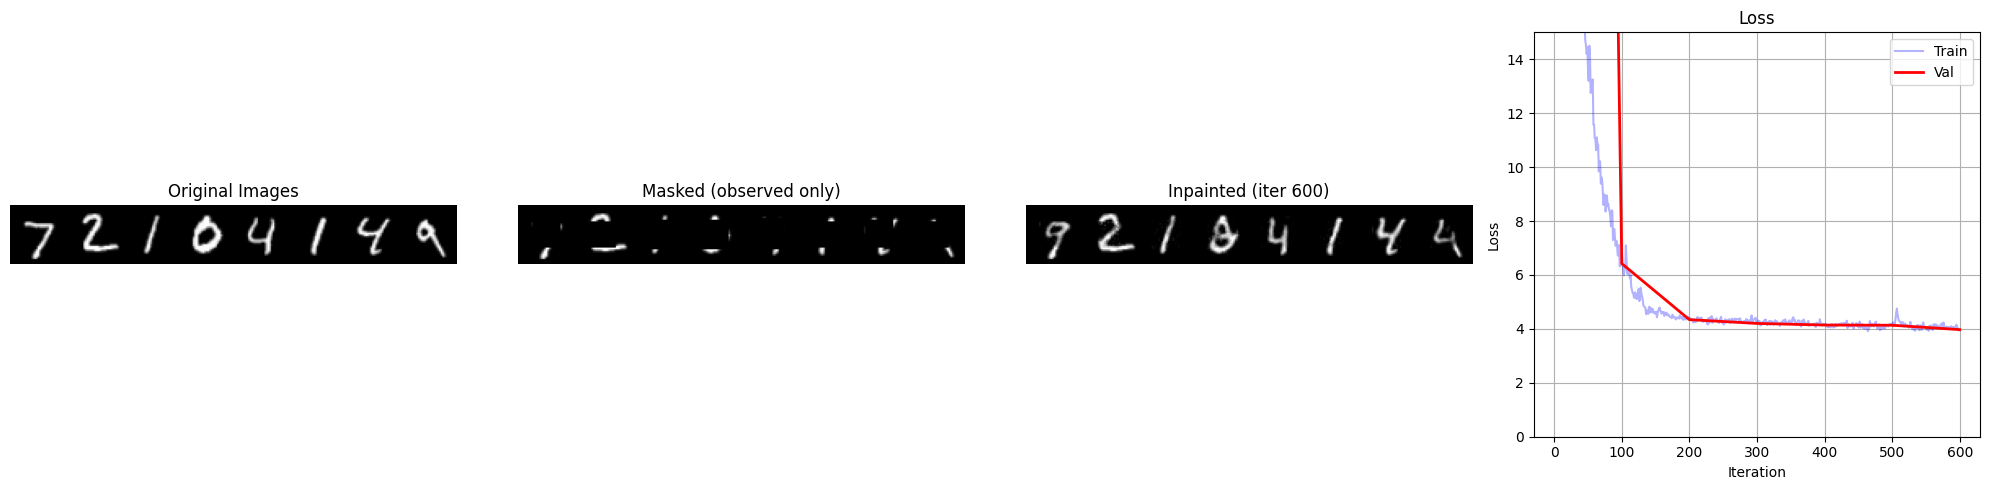

Iter 600 | Train Loss: 3.9469 | Val Loss: 3.9730


  3%|▎         | 608/20000 [12:50<6:49:38,  1.27s/it] 


KeyboardInterrupt: 

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create model
img_size = 32
net = AMFPrecond(
    img_resolution=img_size,
    img_channels=1,
    model_channels=64,  # 64 or 128,  # Base multiplier for the number of channels.
    channel_mult=[2, 2, 2],    # Per-resolution multipliers for the number of channels.
    num_blocks=2,
    use_weight=True
).to(device)

print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")

# Training config with RANDOM BOX SIZES!
min_box_size = 15  # Minimum box size (from 1 pixel...)
max_box_size = 20  # Maximum box size (up to full image size, which
train_params = {
    'max_iter': 20000,
    'batch_size': 256,
    'optimizer_args': {'lr': 2e-4, 'betas': (0.9, 0.99), 'eps': 1e-08},
    'num_workers': 4,
    'val_interval': 100,
    'val_batches': 32,
    'mask_type': 'random_box',  # Use random box sizes for each sample!
    'min_box_size': min_box_size,           # From 1 pixel...
    'max_box_size': max_box_size,          # ...to full 32x32 image
    'device': device,
    'img_size': img_size,
    'checkpoint_path': 'anisotropic_alpha_mf_flowmaps_learned_regularization_correct_part_bs256'
}

# Train
train_loss_history, val_loss_history = train_anisotropic(net, **train_params)

## Test and Visualize

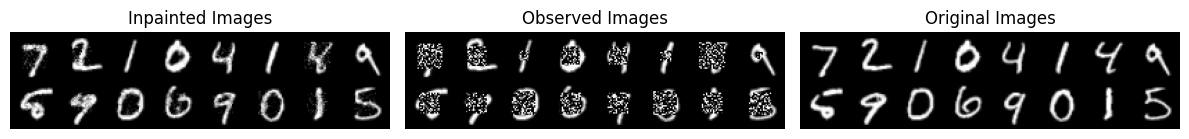

In [11]:
# Load model
min_box_size = 5  # Minimum box size (from 1 pixel...)
max_box_size = 20  # Maximum box size (up to full image size, which

checkpoint = torch.load('save/anisotropic_alpha_mf_flowmaps_learned_regularization_correct_part.pt', weights_only=False)
net.load_state_dict(checkpoint['model'])
net.eval()

# Test
batch_size = 16

test_mask = []
# min_box_size = 1
for _ in range(batch_size):
    box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    test_mask.append(generate_box_mask(1, 1, img_size, img_size, box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]
# test_mask = generate_box_mask(batch_size, 1, img_size, img_size, box_size=16, device=device)

test_dataset = MNIST(
    'data',
    train=False,
    transform=transforms.Compose(list(filter(None, [
        transforms.Resize((img_size, img_size)) if img_size is not None else None,
        transforms.Grayscale(),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ]))),
    download=True
)
dataloader = NextDataLoader(
    test_dataset, batch_size, num_workers=4, prefetch_factor=2, pin_memory=True
)
img = next(dataloader)[0]  # [1, 1, 32, 32]

num_steps = 1
with torch.no_grad():
    z, x_init = sample(net, test_mask, x_observed=img.to(device), device=device, num_steps=num_steps)

# Visualize
x_reconstr = z.detach().permute(0,2,3,1).clamp(0,1)
x_obs = torch.clamp(x_init.permute(0,2,3,1).cpu(), 0, 1)
x_original = img.detach().permute(0,2,3,1).cpu()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title('Inpainted Images')
plt.imshow(grid(x_reconstr.cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Observed Images')
plt.imshow(grid(x_obs).squeeze())
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Original Images')
plt.imshow(grid(x_original.cpu()).squeeze())
plt.axis('off')

plt.tight_layout()
plt.show()